# Demo 1: How a Quantum Program Actually Reaches the Hardware
### The classical transpiler, walked one step at a time on the simplest interesting circuit

When you write a program for a laptop, you never write the 1s and 0s the CPU runs.
A **compiler** translates your code into the *exact* instructions *that specific chip* understands.

Quantum computers need the same thing. It's harder, because a quantum chip has **two**
physical limits the compiler must obey:

1. **It only speaks a few "words."** Every chip supports a tiny fixed set of native gates.
   Your `H` and your `CNOT` are not on the menu. They must be rewritten into what the menu *does* have.
2. **The qubits are wired in a fixed map.** Two qubits can only directly interact if there is a
   physical wire between them. Most pairs have no wire.

The tool that handles both is the **transpiler**. The best everyday analogy:

> **The transpiler is a GPS.** You ask to go from A to B in a straight line. The GPS reroutes you
> onto the roads *that actually exist*, in the *language of turns* the car understands. It tries
> to make the trip as short as possible, because every extra mile adds error.

In this notebook we run a real IBM transpiler on the **smallest circuit worth transpiling: a Bell pair**.
We watch it travel through all **six stages**, one figure at a time.

In [1]:
# --- Notebook 1 setup: everything runs offline, no IBM cloud / no token needed ---
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_gate_map, plot_circuit_layout

# A "fake" backend is a frozen offline snapshot of a real IBM machine:
# same qubit count, same wiring map, same native gate set, same error rates.
backend = FakeTorino()

print("Backend :", backend.name)
print("Qubits  :", backend.num_qubits)
print("Native gates (the only 'words' this chip speaks):")
print("  ", sorted(backend.operation_names))

Backend : fake_torino
Qubits  : 133
Native gates (the only 'words' this chip speaks):
   ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']


## Step 1: Meet the hardware: a map of which qubits can talk

Below is the **coupling map** of this 133-qubit chip. Think of it as a road network:

- each **dot** is a physical qubit,
- each **line** is a physical wire. These are the *only* places where a two-qubit gate is allowed.

This layout is called **heavy-hex**: sparse, with most qubits having just 2-3 neighbours.
Notice there is **no line** between most pairs of dots. If your algorithm needs two qubits to
interact and there's no wire between them, the transpiler has a problem to solve. Keep that in
mind. It's the heart of this whole talk.

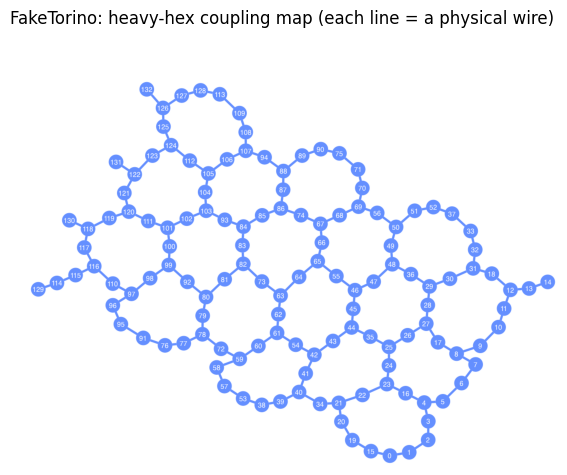

In [2]:
fig = plot_gate_map(backend, figsize=(9, 5))
fig.suptitle("FakeTorino: heavy-hex coupling map (each line = a physical wire)", y=1.02)
fig

## Step 2: The circuit we'll compile: a Bell pair

We deliberately pick the **simplest circuit that still exercises the whole pipeline**: a *Bell pair*.
It is just **three logical operations**:

1. an **H** ("put qubit 0 into a 50/50 superposition"),
2. a **CNOT** ("entangle qubit 0 with qubit 1. They're now linked"),
3. a **measurement** of both.

That's it. Two qubits, one two-qubit gate. Because it's so small, **every change the transpiler makes
is easy to see**. Nothing is hidden in the noise. (We picked exactly the circuit from the thesis,
so these figures match Figures 3-7 there.)

Logical circuit  | depth: 3 | gate counts: {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}


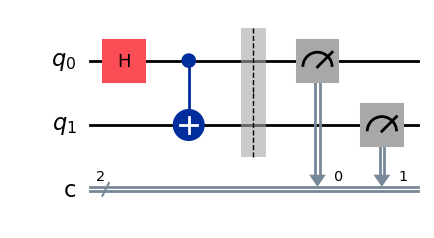

In [3]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()
qc.measure([0, 1], [0, 1])

print("Logical circuit  | depth:", qc.depth(), "| gate counts:", dict(qc.count_ops()))
qc.draw("mpl")

## Step 3: The six stages of the transpiler

IBM's transpiler is a pipeline of **six standard stages**. Here they are in one sentence each
(plain language, full detail comes as we hit each one):

| # | Stage | What it does, in one line |
|---|-------------|---------------------------------------------------------------|
| 1 | **init** | Tidy up the input; break exotic gates into 1- and 2-qubit pieces. |
| 2 | **layout** | Decide *which physical qubit* plays the role of each logical qubit. |
| 3 | **routing** | If two qubits that must interact aren't wired together, insert **SWAP**s to slide them next to each other. |
| 4 | **translation** | Rewrite every gate into the chip's native "words" (`RZ, SX, X, CZ`). |
| 5 | **optimization** | Cancel redundant gates to make the circuit shorter (= less error). |
| 6 | **scheduling** | Assign real timing; fill idle gaps so qubits don't just sit and decay. |

Normally the transpiler runs all six at once and hands you the final circuit. To *teach*, we'll
instead run them **one at a time** and **draw the Bell circuit after each stage**. That way you can watch
it transform. (The cell below sets up that stage-by-stage capture; you don't need to read the code,
just watch the pictures that follow.)

In [4]:
# Build IBM's standard "optimization level 3" pipeline for THIS backend.
pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42)

STAGES = ["init", "layout", "routing", "translation", "optimization", "scheduling"]

def capture_stages(circuit, preset_pm):
    """Run each stage in turn, carrying the PropertySet (layout, coupling map, ...) forward,
    and snapshot the circuit after every stage. Returns {stage_name: circuit}."""
    captured, work, props = {}, circuit.copy(), None
    for s in STAGES:
        sub = getattr(preset_pm, s)
        if sub is None:                       # some stages can be empty (e.g. optional scheduling)
            captured[s] = work.copy()
            continue
        if props is not None:
            sub.property_set.update(props)    # <-- carries the chosen layout into later stages
        work = sub.run(work)
        props = sub.property_set
        captured[s] = work.copy()
    return captured

snaps = capture_stages(qc, pm)

# Quick scoreboard so the audience sees the trend before the pictures:
print(f"{'stage':<13}{'depth':>6}   gate counts")
for s in STAGES:
    c = snaps[s]
    print(f"{s:<13}{c.depth():>6}   {dict(c.count_ops())}")

stage         depth   gate counts
init              3   {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}
layout            3   {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}
routing           3   {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}
translation       8   {'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}
optimization      7   {'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}
scheduling        7   {'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}


## Stage 1: `init`: tidy up the input

> *GPS analogy: straighten out the address you typed before planning the route.*

The transpiler first **pre-processes** the circuit: it unrolls any composite gates into plain
1- and 2-qubit operations and removes obvious algebraic redundancies. For our Bell pair there's
nothing to simplify, so **it comes out unchanged at depth 3**. This is exactly as in the thesis (Fig. 3).
On big circuits this clean-up shrinks the problem *before* the expensive stages run.

*Native passes here include: high-level synthesis, basis pre-translation, inverse cancellation,
removing diagonal gates before measurement.*

After Stage 1 (init) | depth: 3 | ops: {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}


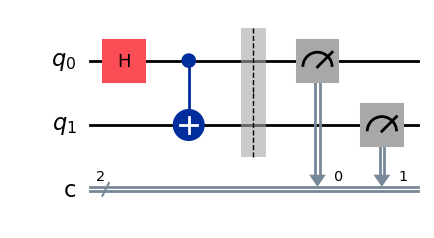

In [5]:
print("After Stage 1 (init) | depth:", snaps["init"].depth(),
      "| ops:", dict(snaps["init"].count_ops()))
snaps["init"].draw("mpl", idle_wires=False, fold=-1)

## Stage 2: `layout`: assign logical qubits to real physical qubits

> *GPS analogy: your "qubit 0" and "qubit 1" are roles; layout casts real actors (physical qubits)
> into those roles.*

Your circuit says "qubit 0" and "qubit 1". But the chip has 133 *specific* qubits, each in a fixed
spot on the map, each with its own error rate. **Layout decides which physical qubit becomes your
qubit 0 and which becomes your qubit 1.** A good choice puts them on low-error qubits that are
*wired together*; a bad choice forces expensive detours later.

From this stage on, the circuit officially lives on the full 133-qubit register (we hide the idle
wires so you only see the two that matter).

![Logical-to-physical mapping](assets/mapping_anim.gif)

*Native passes here: `VF2Layout` (find a wired-together pair that matches your circuit), `SabreLayout`
(a smart stochastic search when SWAPs will be needed), plus manual `SetLayout` and ancilla allocation.*

After Stage 2 (layout) | depth: 3 | ops: {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}
Logical qubit 0 -> physical qubit 51
Logical qubit 1 -> physical qubit 52


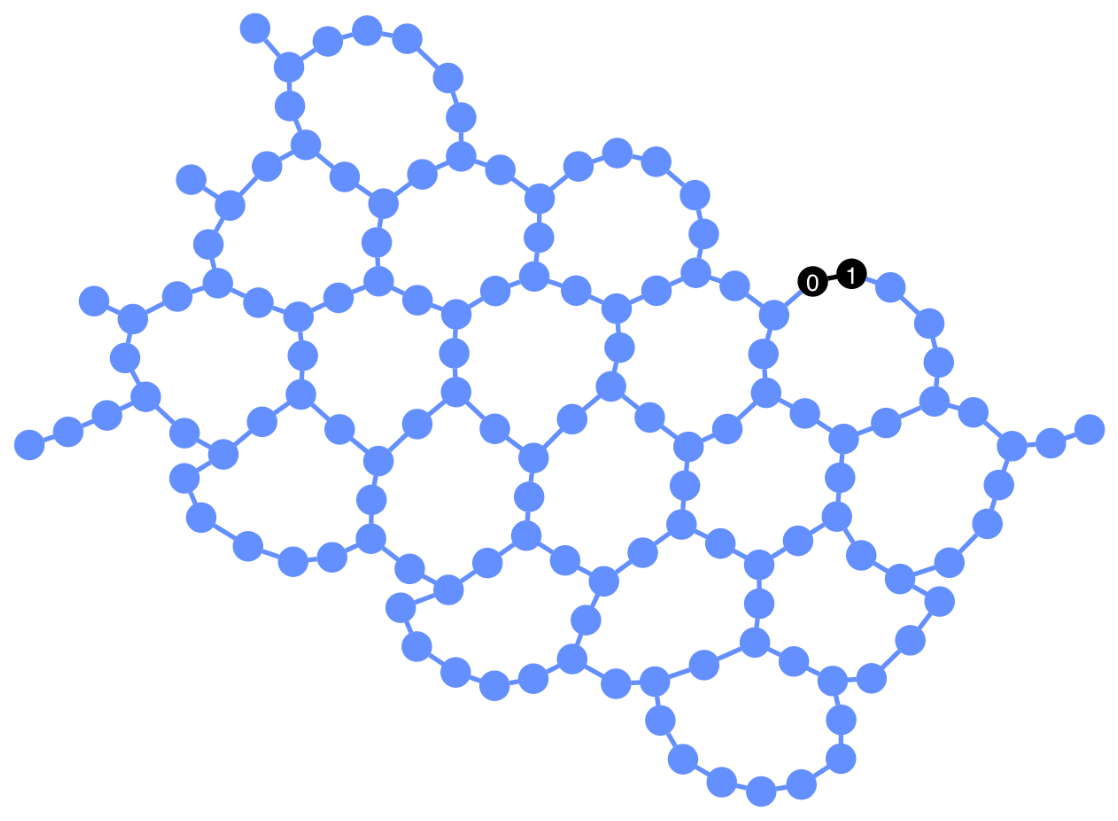

In [6]:
layout_circ = snaps["layout"]
print("After Stage 2 (layout) | depth:", layout_circ.depth(),
      "| ops:", dict(layout_circ.count_ops()))

# Which two PHYSICAL qubits did the transpiler pick for our Bell pair?
final = pm.run(qc)                       # full run, to read the final layout cleanly
phys = [final.layout.final_index_layout()[i] for i in range(qc.num_qubits)]
print("Logical qubit 0 -> physical qubit", phys[0])
print("Logical qubit 1 -> physical qubit", phys[1])

# Show those two qubits highlighted on the chip map:
plot_circuit_layout(final, backend)

## Stage 3: `routing`: make sure interacting qubits are actually neighbours

> *GPS analogy: if there's no direct road, the GPS adds detour turns to get you onto one that exists.*

A two-qubit gate (our CNOT) can **only** run on a pair that's physically wired together. Routing
checks every two-qubit gate. If the two qubits aren't neighbours, it inserts **SWAP** gates to
*physically slide* the quantum states along the wires until they're side by side.

Because our layout already put the Bell pair on **two wired-together qubits**, routing has nothing
to do. **No SWAPs, depth stays 3.** That sounds anticlimactic... so in a moment we'll *deliberately
break it* to see what routing does when the qubits are NOT neighbours. **That is the most important
idea in this whole talk.**

*Native passes here: routing-needed check, `SabreSwap` (inserts the SWAPs), `VF2PostLayout`
(re-pick the best-error mapping afterwards). In the AI transpiler (Demo 2) this is exactly the
stage a trained model replaces.*

After Stage 3 (routing) | depth: 3 | ops: {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}  <-- no 'swap' present


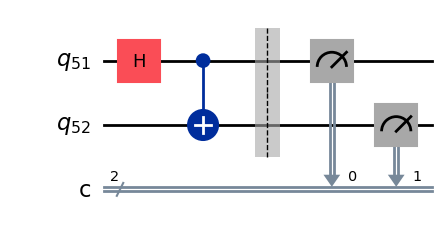

In [7]:
print("After Stage 3 (routing) | depth:", snaps["routing"].depth(),
      "| ops:", dict(snaps["routing"].count_ops()), " <-- no 'swap' present")
snaps["routing"].draw("mpl", idle_wires=False, fold=-1)

## The routing game: the cost of limited connectivity

Here's the beat that makes connectivity *tangible*. We **force** the transpiler to put our Bell pair
on **physical qubits 0 and 2**, which are **NOT** directly wired (the only path is 0-1-2).

Now the CNOT *can't* run: there's no wire between 0 and 2. Routing must insert a **SWAP** to slide
qubit 0's state onto qubit 1, so it sits next to qubit 2.

Watch the price tag:

- a **SWAP is not free**. On real hardware one SWAP is built from **three** native two-qubit gates,
- so this single forced detour turns our **1 two-qubit gate into 4**, and roughly **doubles the depth**.

This is *the* reason quantum compilation is hard, and *the* thing the thesis's AI transpiler attacks:
on bigger circuits these forced SWAPs pile up fast.

![The SWAP routing game](assets/routing_anim.gif)

ADJACENT pair  (lucky layout):  routing ops = {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}
NON-ADJACENT pair (forced 0,2): routing ops = {'measure': 2, 'h': 1, 'swap': 1, 'cx': 1, 'barrier': 1}  <-- a 'swap' appeared!

                       #two-qubit (CZ)   depth
adjacent, final                      1       8
non-adjacent, final                  4      14


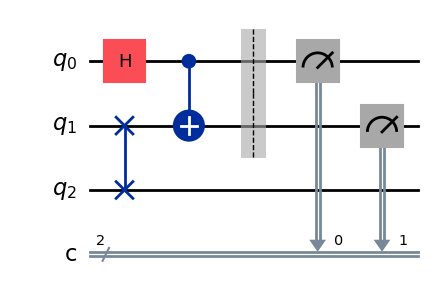

In [8]:
# Force a NON-adjacent placement: physical qubits 0 and 2 (path is 0-1-2, no direct wire).
pm_bad = generate_preset_pass_manager(
    optimization_level=1, backend=backend, initial_layout=[0, 2], seed_transpiler=42
)
snaps_bad = capture_stages(qc, pm_bad)

print("ADJACENT pair  (lucky layout):  routing ops =", dict(snaps["routing"].count_ops()))
print("NON-ADJACENT pair (forced 0,2): routing ops =", dict(snaps_bad["routing"].count_ops()),
      " <-- a 'swap' appeared!")
print()
print(f"{'':22}{'#two-qubit (CZ)':>16}{'depth':>8}")
print(f"{'adjacent, final':22}{snaps['translation'].count_ops().get('cz',0):>16}"
      f"{snaps['translation'].depth():>8}")
print(f"{'non-adjacent, final':22}{snaps_bad['translation'].count_ops().get('cz',0):>16}"
      f"{snaps_bad['translation'].depth():>8}")

# Draw the routed (still high-level) circuit so the inserted SWAP is visible by name:
snaps_bad["routing"].draw("mpl", idle_wires=False, fold=-1)

## Stage 4: `translation`: rewrite everything into the chip's native words

> *GPS analogy: convert the route into the exact turn-by-turn instructions the car understands.
> "In 200 m, turn left," not "head generally north-east."*

The chip cannot run `H` or `CNOT` directly. **Translation rewrites them into the only gates this chip
physically performs:** `RZ`, `SX`, `X`, and the two-qubit `CZ`.

This is where the circuit visibly *grows*. Back on our **lucky adjacent** Bell pair, those 2 friendly
gates (`H` + `CNOT`) become **6× `RZ`, 3× `SX`, 1× `CZ`** and the depth goes from **3 to 8**.
This matches the thesis exactly (Fig. 5). Same quantum operation, just spoken in the hardware's language.

BEFORE translation (logical words): {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}
AFTER  translation (native words) : {'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}
depth: 3 -> 8


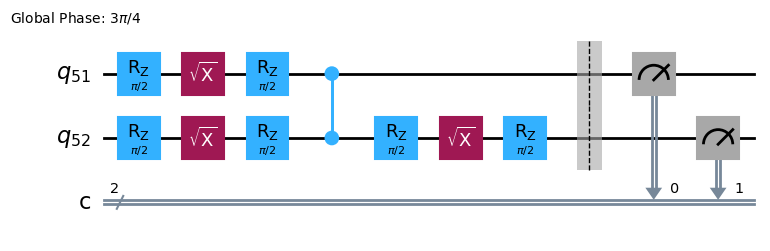

In [9]:
print("BEFORE translation (logical words):", dict(snaps["routing"].count_ops()))
print("AFTER  translation (native words) :", dict(snaps["translation"].count_ops()))
print("depth:", snaps["routing"].depth(), "->", snaps["translation"].depth())
snaps["translation"].draw("mpl", idle_wires=False, fold=-1)

## Stages 5 & 6: `optimization` and `scheduling`: the finishing touches

**Optimization** hunts for gates that cancel or merge. On our Bell pair it absorbs one rotation,
trimming **6 `RZ` → 5** and depth **8 → 7** (thesis Fig. 6). Every gate removed is error removed.
On large circuits this stage matters enormously.

**Scheduling** (optional, last) assigns real clock times and fills idle gaps with `Delay`
instructions so the untouched qubits aren't left silently decaying. The *active* depth stays 7;
the thesis notes 155 idle qubits get padded with delays (Fig. 7). The result is the **final,
hardware-ready, fully-timed circuit.**

That's the whole journey: **2 friendly gates on paper → a timed, native, hardware-legal program.**

FINAL hardware-ready circuit (after all 6 stages)
  depth: 7 | ops: {'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}

Logical Bell we started with : depth 3, ops {'h':1,'cx':1,'measure':2}
On real hardware it becomes  : depth 7 , native gates {'rz': 5, 'sx': 3, 'cz': 1}


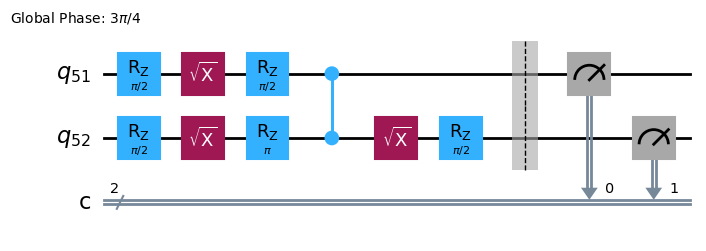

In [10]:
print("FINAL hardware-ready circuit (after all 6 stages)")
print("  depth:", snaps["scheduling"].depth(),
      "| ops:", dict(snaps["scheduling"].count_ops()))
print()
print("Logical Bell we started with : depth 3, ops {'h':1,'cx':1,'measure':2}")
print("On real hardware it becomes  : depth", snaps["optimization"].depth(),
      ", native gates", {k: v for k, v in snaps["optimization"].count_ops().items()
                         if k in ('rz', 'sx', 'cz')})
snaps["optimization"].draw("mpl", idle_wires=False, fold=-1)

## Now scale it up (60 seconds)

We did this on **2 qubits and 1 two-qubit gate**, so every step was visible. Real algorithms are
far bigger. The **exact same six stages** run, just with far more work at each one.

The thesis applies this very pipeline to a **QAOA / MaxCut** circuit (Figs. 8-9). Even on a tiny
4-node problem, the transpiled circuit ends up with **~7× more gates and ~11× the depth** of the
logical version. That ratio **grows with problem size**. Almost all of that blow-up comes from
**Stage 3, routing**. These are the forced SWAPs we just saw, multiplied hundreds of times.

**That is the bottleneck Demo 2 attacks:** can an AI learn a *smarter* routing strategy than the
classical heuristic, specifically for IBM's new **square-lattice** chips? → On to Notebook 2.